---
title: "RBIG warm-start for parametric flows"
short_title: "01 · RBIG warm-start"
subtitle: "Seed a trainable Gaussianization flow with a greedy RBIG fit, then fine-tune — the data-driven head start beats training from scratch"
description: >
  A greedy RBIG fit (Part 3) needs no gradients and already Gaussianizes well; a
  parametric flow (notebook 00) trains to the same quality but starts from a random
  initialisation. Because fit_rbig and gaussianization_flow share the same
  structure, the RBIG fit is a valid initialisation for the trainable flow. This
  notebook warm-starts from RBIG and fine-tunes with optax — converging in a
  fraction of the steps and to a better optimum than the random start.
---

(sec-nb-para-01)=
# 01 — RBIG warm-start for parametric flows

Two facts from earlier parts sit naturally together. Greedy **RBIG**
{cite}`laparra2011rbig` (Part 3)
fits each rotation + marginal block once, with no gradients, and already
Gaussianizes well — but it never jointly optimises the stack. A **parametric**
flow ([notebook 00](00_nll_training.ipynb)) does optimise jointly by NLL, but
starts from a *random* initialisation and pays thousands of gradient steps to
catch up. The obvious move is to **warm-start**: use the greedy RBIG fit as the
*initialisation* of the trainable flow, then fine-tune.

This works in `gauss_flows` because `fit_rbig` and `gaussianization_flow` return
the **same bijector structure** (we saw both are an `Invert`-wrapped stack of
rotation + mixture-CDF layers). So a fitted RBIG model is, literally, a
trainable flow whose parameters happen to be good already — we can hand it
straight to the same `optax` loop.

**What you will see**

- A greedy `fit_rbig` model used directly as the **initialisation** of the
  trainable flow (NLL $\approx 2$ at step 0, vs $\approx 17$ for a random start).
- **Cold vs warm** NLL trajectories: warm-start begins where cold-start *ends*.
- At an **equal training budget**, warm-start reaching a **better** optimum than
  either greedy or cold — and why fine-tuning uses a more moderate learning rate.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from sklearn.datasets import make_moons

import gauss_flows as gf
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

X, _ = make_moons(n_samples=3000, noise=0.08, random_state=0)
X = jnp.asarray((X - X.mean(0)) / X.std(0))


def train_flow(flow, *, steps, peak_lr, clip_norm=1.0, batch=512, seed=1):
    """NLL training (optax: gradient clipping + one-cycle cosine LR). Returns
    the fitted flow and the NLL trajectory (sampled every 25 steps)."""
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    schedule = optax.cosine_onecycle_schedule(transition_steps=steps, peak_value=peak_lr)
    opt = optax.chain(optax.clip_by_global_norm(clip_norm), optax.adam(schedule))
    state = opt.init(params)

    @eqx.filter_jit
    def step(params, state, xb):
        loss, grads = eqx.filter_value_and_grad(
            lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(xb)))(params)
        updates, state = opt.update(grads, state)
        return eqx.apply_updates(params, updates), state, loss

    key, traj = jr.key(seed), []
    for i in range(steps):
        key, sk = jr.split(key)
        idx = jr.randint(sk, (batch,), 0, X.shape[0])
        params, state, loss = step(params, state, X[idx])
        if i % 25 == 0:
            traj.append(float(loss))
    return eqx.combine(params, static), np.array(traj)


nll = lambda flow: -float(jax.vmap(flow.log_prob)(X).mean())

## 1. A greedy RBIG fit *is* an initialisation

We build the two starting points: a randomly-initialised `gaussianization_flow`
(the cold start of notebook 00) and a greedy `fit_rbig` model (Part 3). Both are
the same kind of object — a `Transformed` with an `Invert`-wrapped layer stack —
so both can be fed to `train_flow`. The difference is where they *start*.

In [2]:
cold_init = gf.gaussianization_flow(jr.key(0), n_dims=2, n_layers=8, n_components=8)
warm_init = gf.fit_rbig(X, n_layers=8, n_components=8, random_state=0)

print(f"same bijector structure? {type(cold_init.bijection).__name__} == "
      f"{type(warm_init.bijection).__name__}: "
      f"{type(cold_init.bijection).__name__ == type(warm_init.bijection).__name__}")
print(f"cold start (random)      NLL at step 0 = {nll(cold_init):6.3f}")
print(f"warm start (greedy RBIG) NLL at step 0 = {nll(warm_init):6.3f}")

same bijector structure? Invert == Invert: True


cold start (random)      NLL at step 0 = 16.934


warm start (greedy RBIG) NLL at step 0 =  1.957


The greedy RBIG fit opens at NLL $\approx 2$ — essentially the value the cold
start spends thousands of gradient steps to reach. It is a free, data-driven head
start. Now we fine-tune it.

## 2. Cold vs warm: the NLL trajectories

We train both for the **same budget** (3000 steps) with the same `optax` loop, but
at **different learning rates**, and this matters. The cold start is far from any
optimum, so it wants a large peak LR ($3\times10^{-3}$) to make progress. The warm
start is *already near* a good optimum, so it uses a more moderate LR
($10^{-3}$) — a large one-cycle peak would kick it away and undo RBIG's work.

cold: NLL 16.93 -> 1.978  (reaches < 2.1 at step 1700)


warm: NLL 1.93 -> 1.657  (below 2.1 from step 0)


greedy RBIG (no training): 1.957


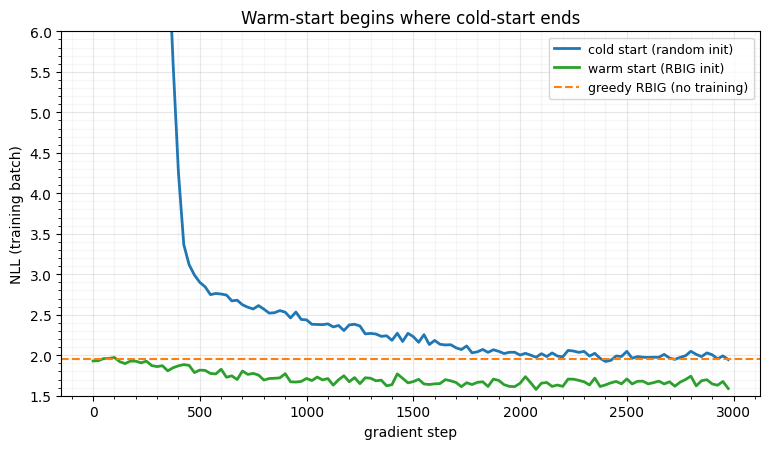

In [3]:
STEPS = 3000
cold, traj_cold = train_flow(cold_init, steps=STEPS, peak_lr=3e-3)
warm, traj_warm = train_flow(warm_init, steps=STEPS, peak_lr=1e-3)

def steps_to(traj, thr=2.1):
    i = next((k for k, v in enumerate(traj) if v < thr), None)
    return None if i is None else i * 25

print(f"cold: NLL {traj_cold[0]:.2f} -> {nll(cold):.3f}  "
      f"(reaches < 2.1 at step {steps_to(traj_cold)})")
print(f"warm: NLL {traj_warm[0]:.2f} -> {nll(warm):.3f}  "
      f"(below 2.1 from step 0)")
print(f"greedy RBIG (no training): {nll(warm_init):.3f}")

fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.plot(np.arange(len(traj_cold)) * 25, traj_cold, color="tab:blue", lw=2, label="cold start (random init)")
ax.plot(np.arange(len(traj_warm)) * 25, traj_warm, color="tab:green", lw=2, label="warm start (RBIG init)")
ax.axhline(nll(warm_init), color="tab:orange", lw=1.5, ls="--", label="greedy RBIG (no training)")
ax.set(title="Warm-start begins where cold-start ends",
       xlabel="gradient step", ylabel="NLL (training batch)", ylim=(1.5, 6))
ax.legend(fontsize=9); style_ax(ax)
fig.tight_layout()

At an equal budget the cold curve plunges from $\approx 17$ (off the top of the
axis) and only reaches the warm start's *opening* value after well over a thousand
steps. The warm curve starts at RBIG's NLL and improves past it, staying below the
cold curve the whole way. Same architecture, same optimiser, same step budget — the
initialisation is the whole story.

## 3. Warm-start wins on speed and quality

Fine-tuning does more than save steps: by jointly optimising all layers from
RBIG's per-layer-greedy solution, it finds a **better** optimum than either the
greedy fit or the cold-trained flow. We compare the three on held-out likelihood
and on the learned density.

final mean log p(x) after 3000 steps each (higher is better):


  greedy RBIG (no training) : -1.957


  cold start (random init)  : -1.978


  warm start (RBIG init)    : -1.657   <- best, and ahead the whole way


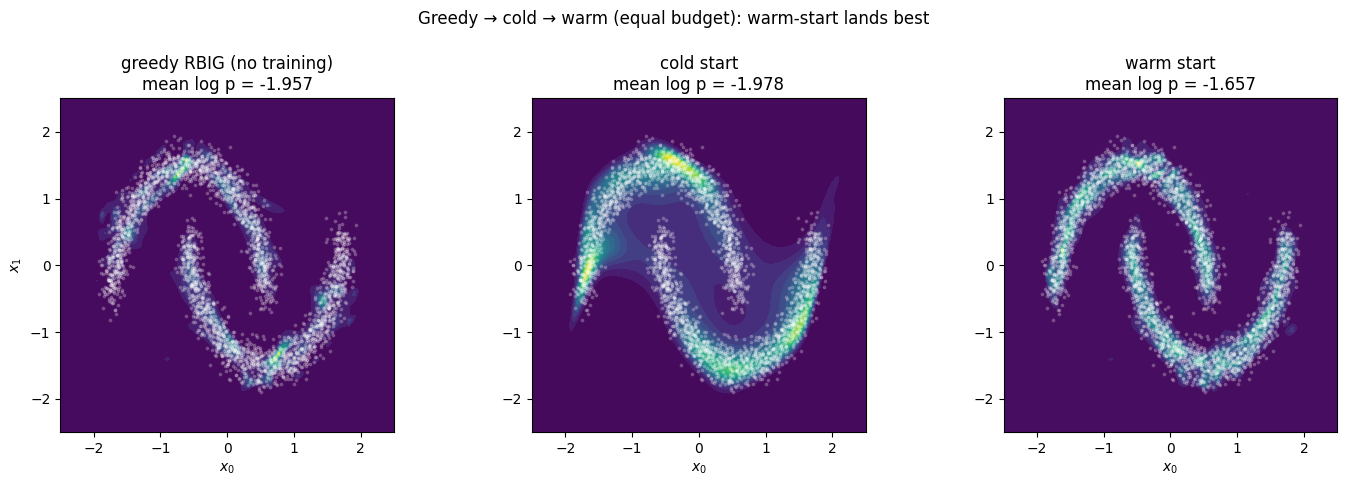

In [4]:
print(f"final mean log p(x) after {STEPS} steps each (higher is better):")
print(f"  greedy RBIG (no training) : {-nll(warm_init):.3f}")
print(f"  cold start (random init)  : {-nll(cold):.3f}")
print(f"  warm start (RBIG init)    : {-nll(warm):.3f}   <- best, and ahead the whole way")

gx, gy = np.meshgrid(np.linspace(-2.5, 2.5, 120), np.linspace(-2.5, 2.5, 120))
grid = jnp.asarray(np.column_stack([gx.ravel(), gy.ravel()]))
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6))
for ax, model, t in [(axes[0], warm_init, "greedy RBIG (no training)"),
                     (axes[1], cold, "cold start"),
                     (axes[2], warm, "warm start")]:
    lp = np.asarray(jax.vmap(model.log_prob)(grid)).reshape(gx.shape)
    ax.contourf(gx, gy, np.exp(lp), levels=18, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], s=3, color="white", alpha=0.2)
    ax.set(title=f"{t}\nmean log p = {-nll(model):.3f}", xlabel="$x_0$")
    ax.set_aspect("equal")
axes[0].set_ylabel("$x_1$")
fig.suptitle("Greedy → cold → warm (equal budget): warm-start lands best", y=1.02)
fig.tight_layout()

Warm-start delivers the best fit for a fraction of the compute: it inherits RBIG's
data-driven structure and then lets gradients refine the whole stack jointly. This
is the bridge the master list calls *iterative Gaussianization warm-start* — fit
greedily, then fine-tune — and it is the practical recipe for parametric
Gaussianization at scale: never start a flow from noise when a cheap RBIG fit can
put it most of the way there.

## Recap

| start | init NLL | training (3000 steps) | final $\log p$ |
|---|---|---|---|
| greedy RBIG | — | none (greedy) | $-1.96$ |
| cold (random) | $\approx 17$ | lr $3\!\times\!10^{-3}$ | $-1.98$ |
| **warm (RBIG)** | $\approx 2$ | lr $10^{-3}$ | $\mathbf{-1.66}$ (best) |

- `fit_rbig` and `gaussianization_flow` share a structure, so a greedy fit is a
  drop-in **initialisation** for the trainable flow.
- At an equal budget the warm start begins where the cold start *ends*, stays ahead
  the whole way, and fine-tunes **past** both the cold flow and the greedy fit.
- Fine-tuning uses a **moderate** LR — a large one-cycle peak would undo the good init.

**Next up.** We have trained and warm-started flows but read only the final
likelihood. [02 — Layer-wise inspection](02_layerwise_inspection.ipynb) opens a flow
up — pushing data through one layer at a time to watch Gaussianity improve and
diagnose *where* in the stack the work happens. (The **coupling** flow itself — and
its warm-start — is the subject of Part 5.)